In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示和图形样式
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
sns.set_palette("husl")

# 读取数据
df = pd.read_csv('D:/桌面/高雄市空气污染源数据.csv')

print("数据集形状:", df.shape)
print("\n前5行数据:")
print(df.head())
print("\n数据信息:")
print(df.info())
print("\n统计描述:")
print(df.describe())

# 检查缺失值
print("\n缺失值统计:")
print(df.isnull().sum())

数据集形状: (223971, 23)

前5行数据:
              date  sitename   aqi pollutant status  so2    co    o3  o3_8hr  \
0  2024/8/31 23:00   Zuoying  38.0       NaN   Good  2.4  0.30  23.6    41.8   
1  2024/8/31 23:00   Meinong  43.0       NaN   Good  0.5  0.17  32.4    46.1   
2  2024/8/31 23:00   Linyuan  38.0       NaN   Good  1.5  0.23  30.0    41.0   
3  2024/8/31 23:00   Qianjin  37.0       NaN   Good  1.1  0.34  28.6    40.8   
4  2024/8/31 23:00  Xiaogang  35.0       NaN   Good  0.5  0.26  33.3    39.0   

   pm10  ...   no  windspeed  winddirec  co_8hr  pm2.5_avg  pm10_avg  so2_avg  \
0  21.0  ...  0.5        1.5        2.0     0.2       10.2      18.0      1.0   
1  14.0  ...  0.9        0.4       55.0     0.1        7.5      21.0      0.0   
2  25.0  ...  0.6        1.0       59.0     0.2       11.5      25.0      1.0   
3  20.0  ...  0.5        0.8        2.0     0.2        8.7      18.0      1.0   
4   9.0  ...  1.5        1.1       31.0     0.2       10.8      12.0      1.0   

    

In [2]:
# 1. 处理日期时间列
df['date'] = pd.to_datetime(df['date'])
df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# 2. 填充缺失值（使用前向填充）
numeric_cols = ['so2', 'co', 'o3', 'o3_8hr', 'pm10', 'pm2.5', 'no2', 'nox', 'no', 
                'windspeed', 'winddirec', 'co_8hr', 'pm2.5_avg', 'pm10_avg', 'so2_avg']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(method='ffill').fillna(method='bfill')

# 3. 创建空气质量等级分类
def categorize_aqi(aqi):
    if pd.isna(aqi):
        return 'Unknown'
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Moderate'
    elif aqi <= 150:
        return 'Unhealthy for Sensitive Groups'
    elif aqi <= 200:
        return 'Unhealthy'
    elif aqi <= 300:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

df['aqi_category'] = df['aqi'].apply(categorize_aqi)

# 4. 添加季节信息
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['season'] = df['month'].apply(get_season)

print("\n数据预处理完成!")
print(f"时间范围: {df['date'].min()} 到 {df['date'].max()}")
print(f"站点数量: {df['sitename'].nunique()}")
print(f"唯一站点: {df['sitename'].unique().tolist()}")


数据预处理完成!
时间范围: 2020-01-01 00:00:00 到 2024-08-31 23:00:00
站点数量: 5
唯一站点: ['Zuoying', 'Meinong', 'Linyuan', 'Qianjin', 'Xiaogang']


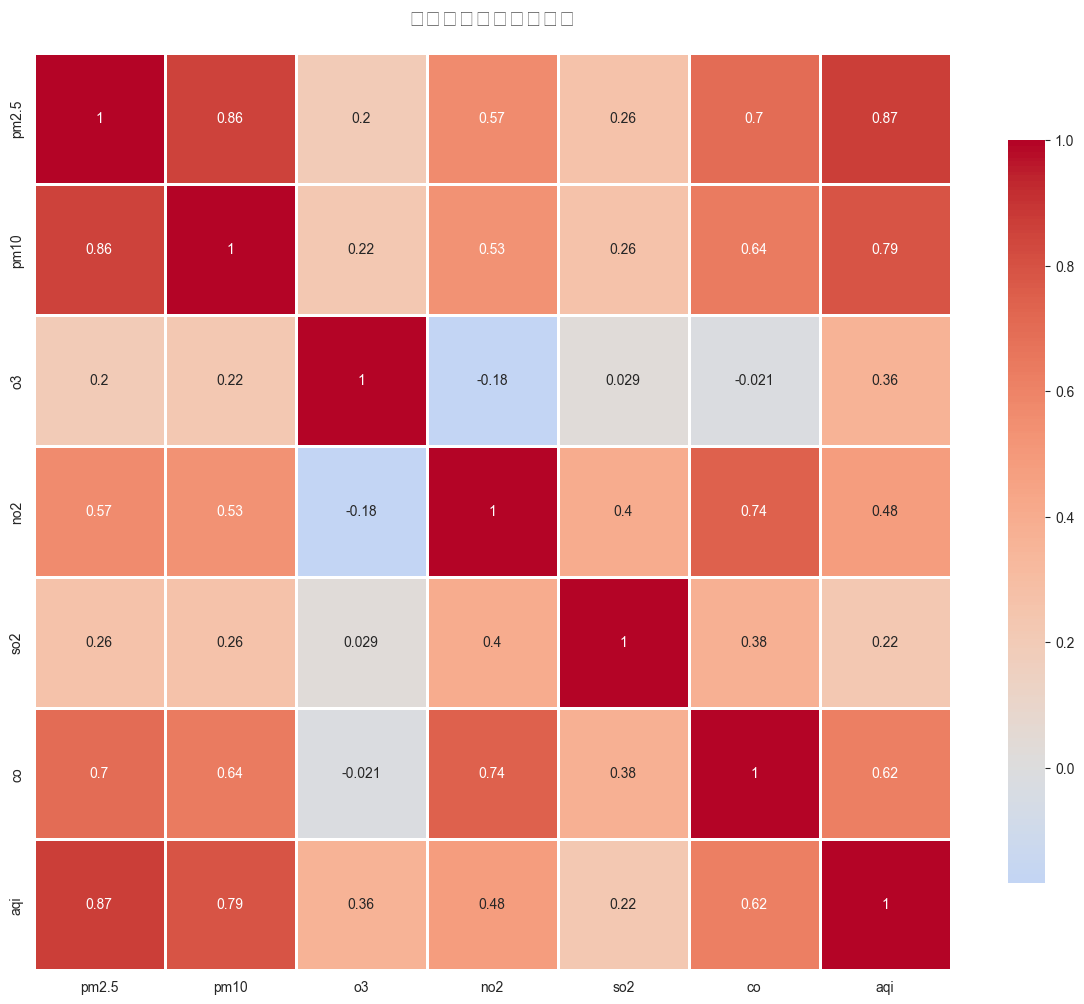

<Figure size 1400x1000 with 0 Axes>

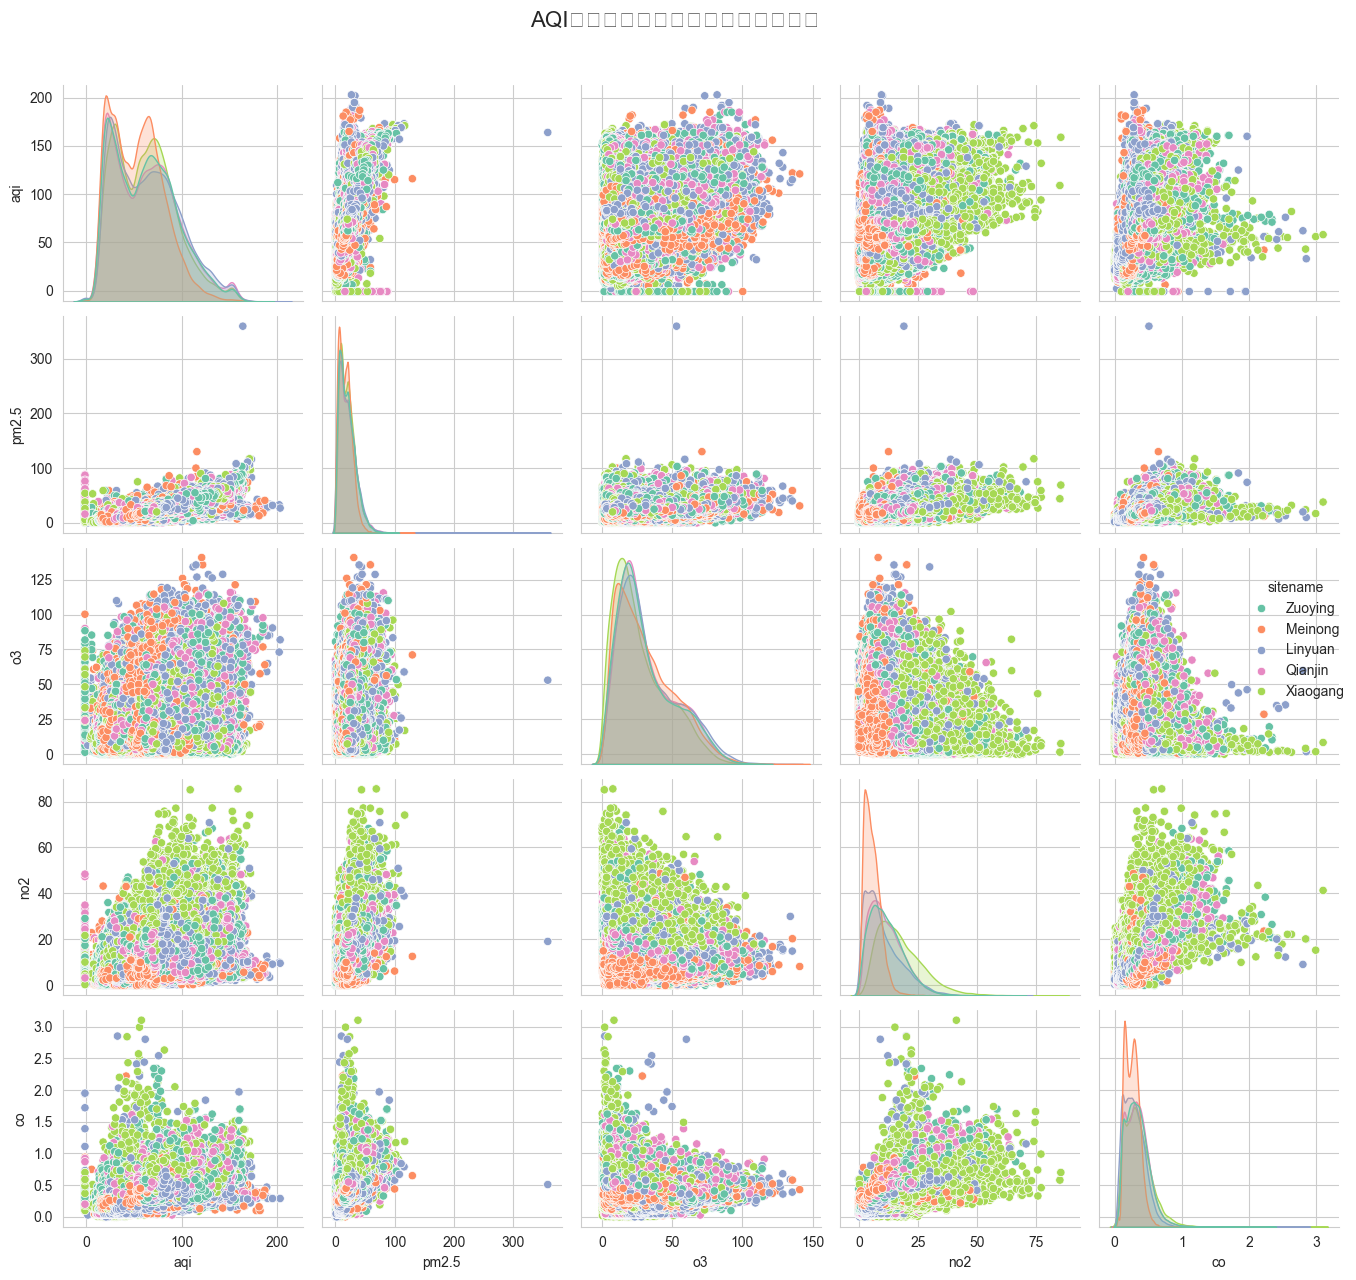

In [3]:
# 选择主要污染物进行分析
pollutants = ['pm2.5', 'pm10', 'o3', 'no2', 'so2', 'co', 'aqi']
pollutant_df = df[pollutants]

# 计算相关性矩阵
correlation_matrix = pollutant_df.corr()

# 绘制相关性热图
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": .8})
plt.title('污染物相关性矩阵热图', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# 绘制AQI与各污染物的散点图矩阵
pollutants_for_pairplot = ['aqi', 'pm2.5', 'o3', 'no2', 'co']
plt.figure(figsize=(14, 10))
sns.pairplot(df[pollutants_for_pairplot + ['sitename']], 
             hue='sitename', diag_kind='kde', palette='Set2')
plt.suptitle('AQI与主要污染物分布关系（按站点）', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

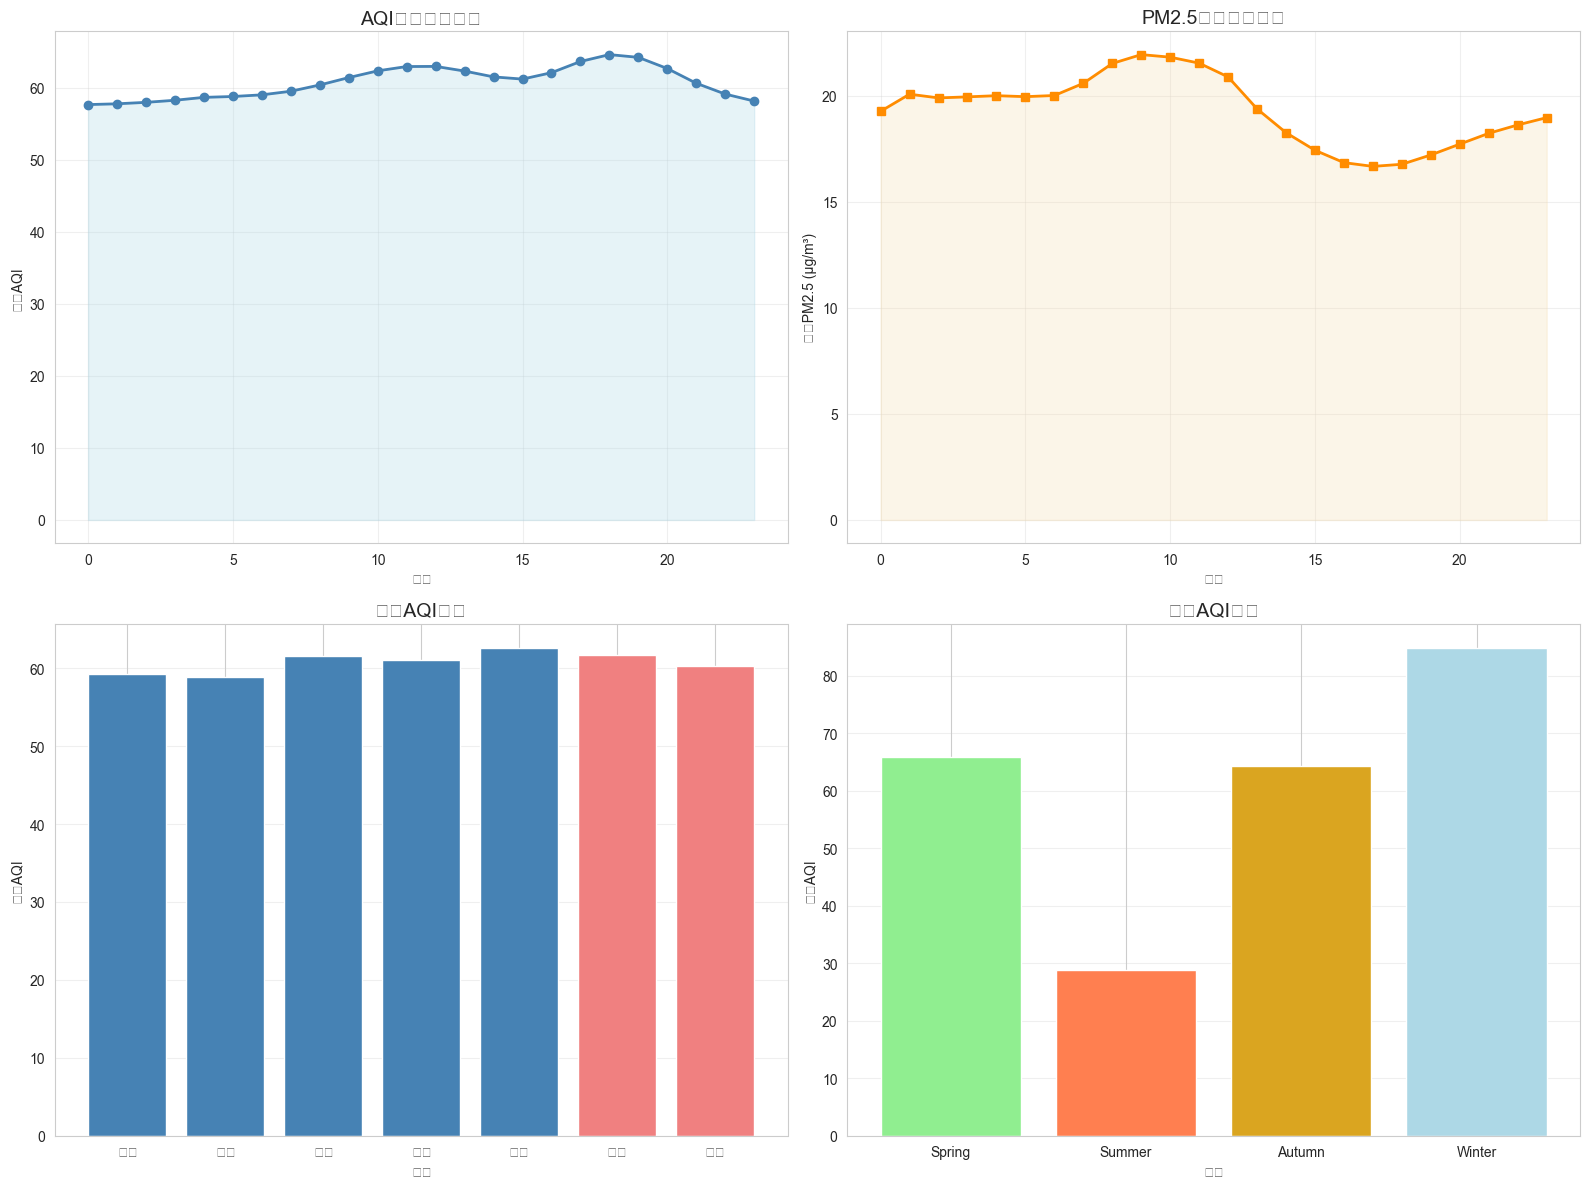

In [4]:
# 按小时分析污染物浓度变化
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 按小时平均AQI
hourly_avg = df.groupby('hour')['aqi'].mean()
axes[0, 0].plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2, color='steelblue')
axes[0, 0].fill_between(hourly_avg.index, hourly_avg.values, alpha=0.3, color='lightblue')
axes[0, 0].set_title('AQI小时变化趋势', fontsize=14)
axes[0, 0].set_xlabel('小时')
axes[0, 0].set_ylabel('平均AQI')
axes[0, 0].grid(True, alpha=0.3)

# 2. 按小时平均PM2.5
hourly_pm25 = df.groupby('hour')['pm2.5'].mean()
axes[0, 1].plot(hourly_pm25.index, hourly_pm25.values, marker='s', linewidth=2, color='darkorange')
axes[0, 1].fill_between(hourly_pm25.index, hourly_pm25.values, alpha=0.3, color='wheat')
axes[0, 1].set_title('PM2.5小时变化趋势', fontsize=14)
axes[0, 1].set_xlabel('小时')
axes[0, 1].set_ylabel('平均PM2.5 (μg/m³)')
axes[0, 1].grid(True, alpha=0.3)

# 3. 按星期分析
weekday_names = ['周一', '周二', '周三', '周四', '周五', '周六', '周日']
weekly_avg = df.groupby('day_of_week')['aqi'].mean()
axes[1, 0].bar(weekly_avg.index, weekly_avg.values, color=['steelblue' if i<5 else 'lightcoral' for i in range(7)])
axes[1, 0].set_title('周内AQI变化', fontsize=14)
axes[1, 0].set_xlabel('星期')
axes[1, 0].set_ylabel('平均AQI')
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(weekday_names)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. 季节变化
seasonal_avg = df.groupby('season')['aqi'].mean()
seasons_order = ['Spring', 'Summer', 'Autumn', 'Winter']
seasonal_avg = seasonal_avg.reindex(seasons_order)
colors = ['lightgreen', 'coral', 'goldenrod', 'lightblue']
axes[1, 1].bar(seasonal_avg.index, seasonal_avg.values, color=colors)
axes[1, 1].set_title('季节AQI变化', fontsize=14)
axes[1, 1].set_xlabel('季节')
axes[1, 1].set_ylabel('平均AQI')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

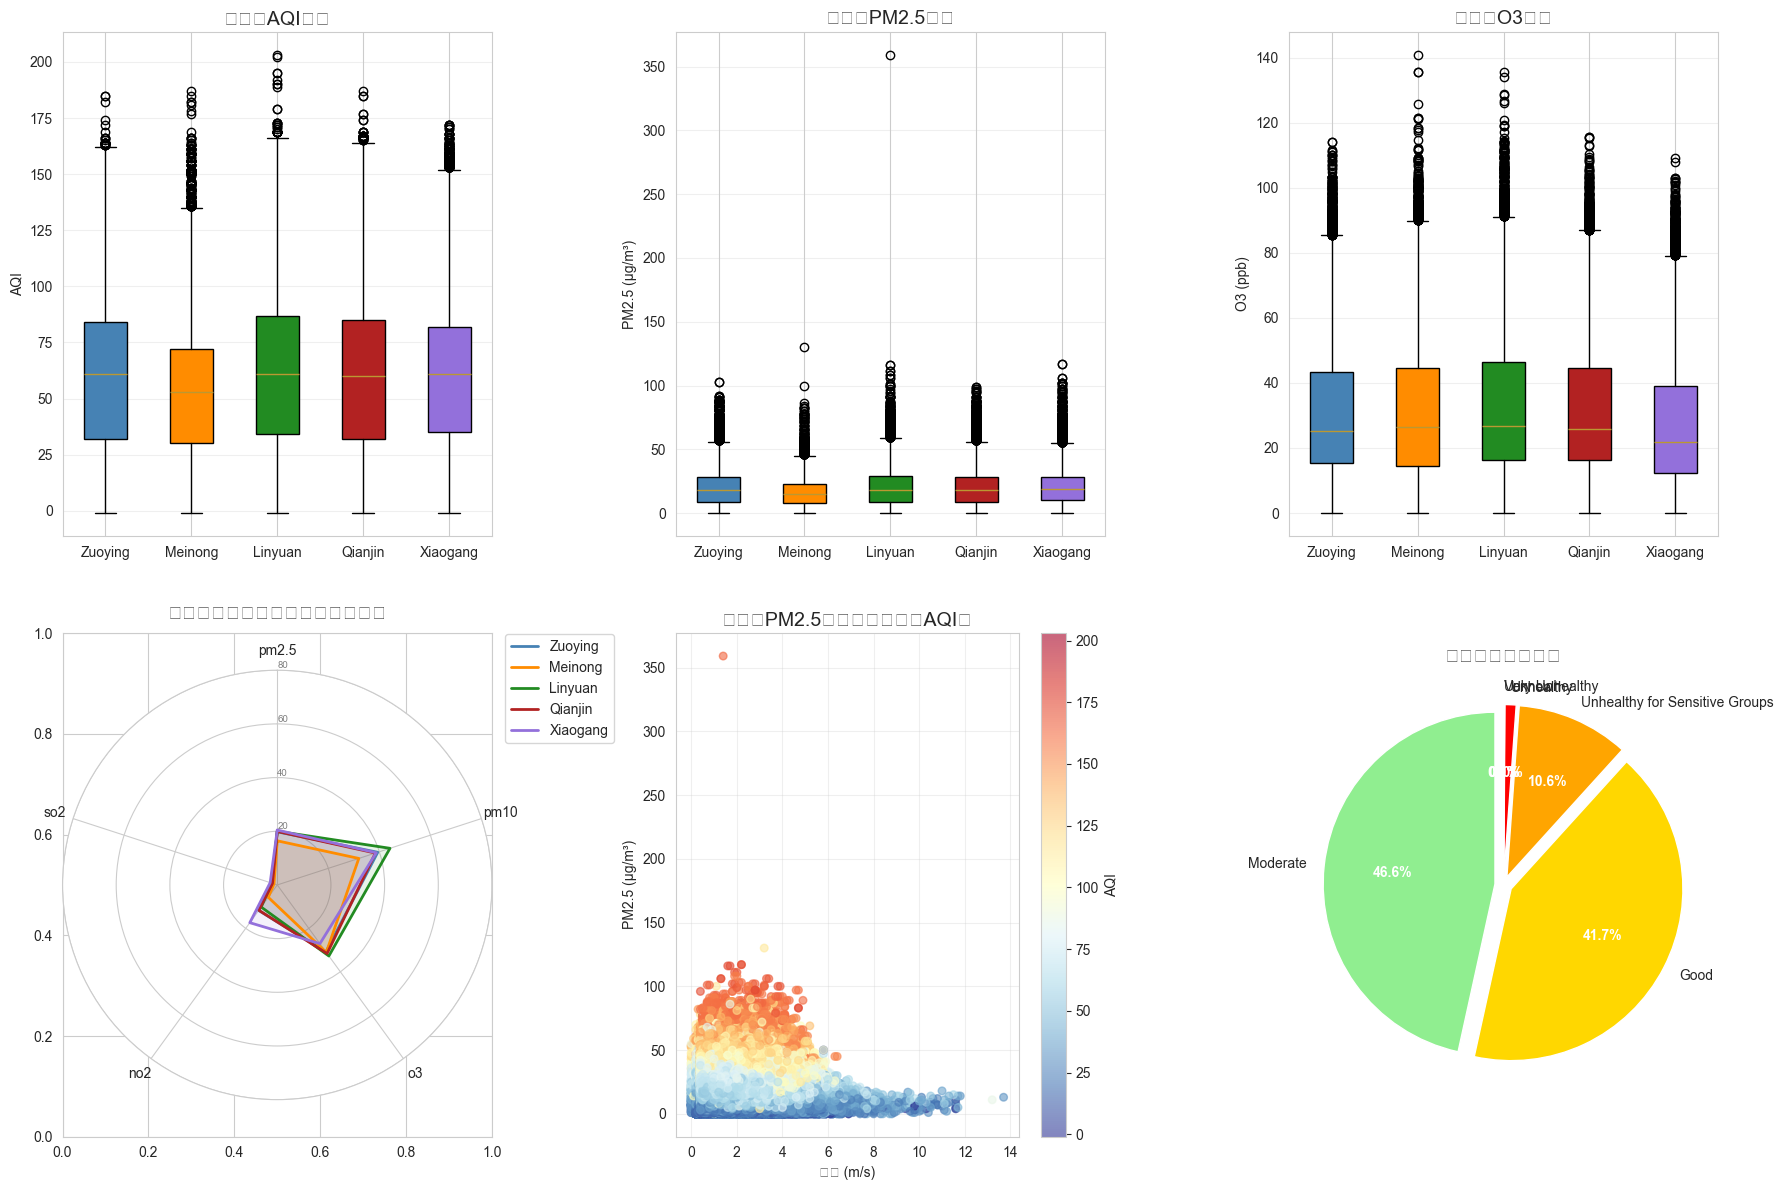

In [5]:
# 各站点污染物浓度比较
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
sites = df['sitename'].unique()
site_colors = ['steelblue', 'darkorange', 'forestgreen', 'firebrick', 'mediumpurple']

# 1. 各站点AQI箱线图
site_aqi_data = [df[df['sitename']==site]['aqi'].dropna() for site in sites]
bp1 = axes[0, 0].boxplot(site_aqi_data, patch_artist=True, labels=sites)
for patch, color in zip(bp1['boxes'], site_colors):
    patch.set_facecolor(color)
axes[0, 0].set_title('各站点AQI分布', fontsize=14)
axes[0, 0].set_ylabel('AQI')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. 各站点PM2.5箱线图
site_pm25_data = [df[df['sitename']==site]['pm2.5'].dropna() for site in sites]
bp2 = axes[0, 1].boxplot(site_pm25_data, patch_artist=True, labels=sites)
for patch, color in zip(bp2['boxes'], site_colors):
    patch.set_facecolor(color)
axes[0, 1].set_title('各站点PM2.5分布', fontsize=14)
axes[0, 1].set_ylabel('PM2.5 (μg/m³)')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. 各站点O3箱线图
site_o3_data = [df[df['sitename']==site]['o3'].dropna() for site in sites]
bp3 = axes[0, 2].boxplot(site_o3_data, patch_artist=True, labels=sites)
for patch, color in zip(bp3['boxes'], site_colors):
    patch.set_facecolor(color)
axes[0, 2].set_title('各站点O3分布', fontsize=14)
axes[0, 2].set_ylabel('O3 (ppb)')
axes[0, 2].grid(True, alpha=0.3, axis='y')

# 4. 各站点污染物平均浓度雷达图
from math import pi

# 准备数据
pollutants_radar = ['pm2.5', 'pm10', 'o3', 'no2', 'so2']
site_avg_pollutants = {}
for site in sites:
    site_data = df[df['sitename']==site]
    site_avg = [site_data[p].mean() for p in pollutants_radar]
    site_avg_pollutants[site] = site_avg

# 绘制雷达图
angles = [n / float(len(pollutants_radar)) * 2 * pi for n in range(len(pollutants_radar))]
angles += angles[:1]

ax = plt.subplot(2, 3, 4, polar=True)
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)

plt.xticks(angles[:-1], pollutants_radar)
ax.set_rlabel_position(0)
plt.yticks([20, 40, 60, 80], ["20", "40", "60", "80"], color="grey", size=7)
plt.ylim(0, 80)

for i, (site, values) in enumerate(site_avg_pollutants.items()):
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=site, color=site_colors[i])
    ax.fill(angles, values, alpha=0.1, color=site_colors[i])

plt.title('各站点主要污染物平均浓度雷达图', size=14, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

# 5. 风速风向与污染物关系
ax5 = axes[1, 1]
scatter = ax5.scatter(df['windspeed'], df['pm2.5'], c=df['aqi'], 
                      cmap='RdYlBu_r', alpha=0.6, s=30)
ax5.set_xlabel('风速 (m/s)')
ax5.set_ylabel('PM2.5 (μg/m³)')
ax5.set_title('风速与PM2.5关系（颜色表示AQI）', fontsize=14)
plt.colorbar(scatter, ax=ax5, label='AQI')
ax5.grid(True, alpha=0.3)

# 6. 空气质量等级分布
ax6 = axes[1, 2]
aqi_counts = df['aqi_category'].value_counts()
colors_category = ['lightgreen', 'gold', 'orange', 'red', 'purple', 'gray']
wedges, texts, autotexts = ax6.pie(aqi_counts.values, labels=aqi_counts.index, 
                                   autopct='%1.1f%%', colors=colors_category,
                                   startangle=90, explode=[0.05]*len(aqi_counts))
ax6.set_title('空气质量等级分布', fontsize=14)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

回归模型性能评估

线性回归:
  均方误差 (MSE): 203.42
  均方根误差 (RMSE): 14.26
  平均绝对误差 (MAE): 10.09
  决定系数 (R²): 0.8036

随机森林:
  均方误差 (MSE): 127.86
  均方根误差 (RMSE): 11.31
  平均绝对误差 (MAE): 7.75
  决定系数 (R²): 0.8766


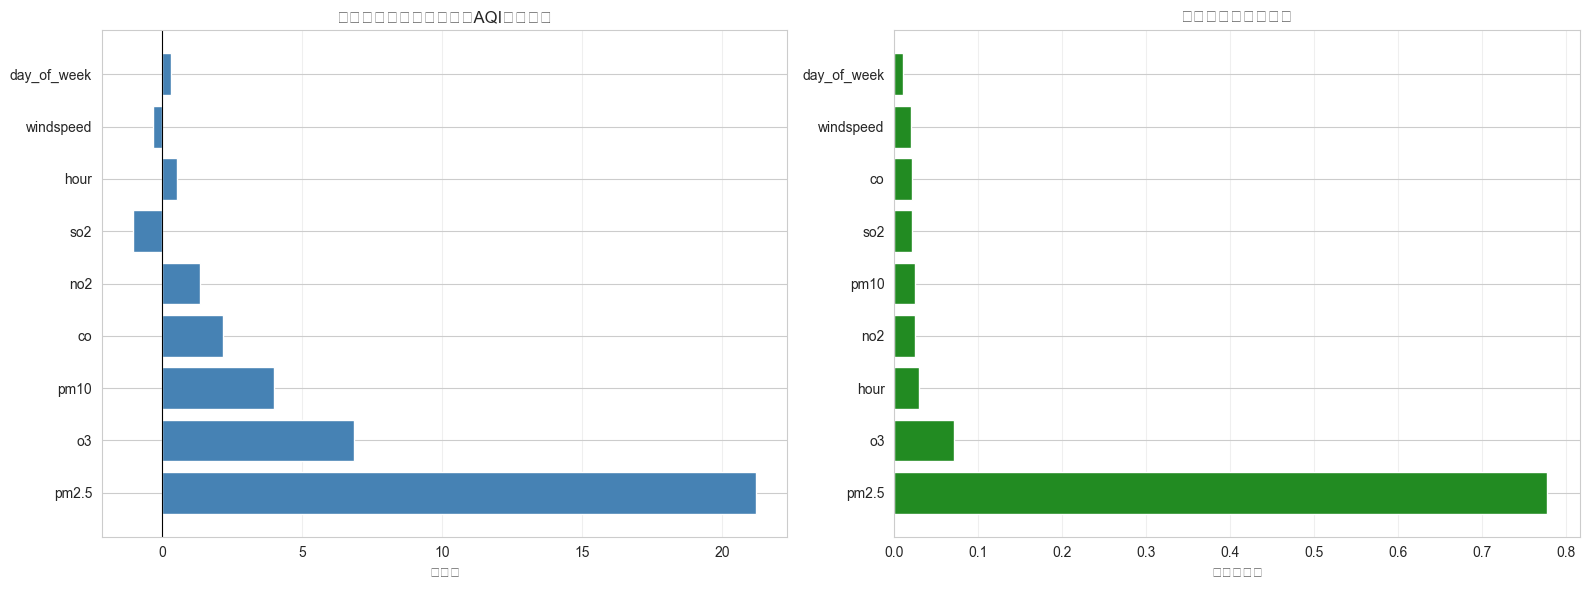

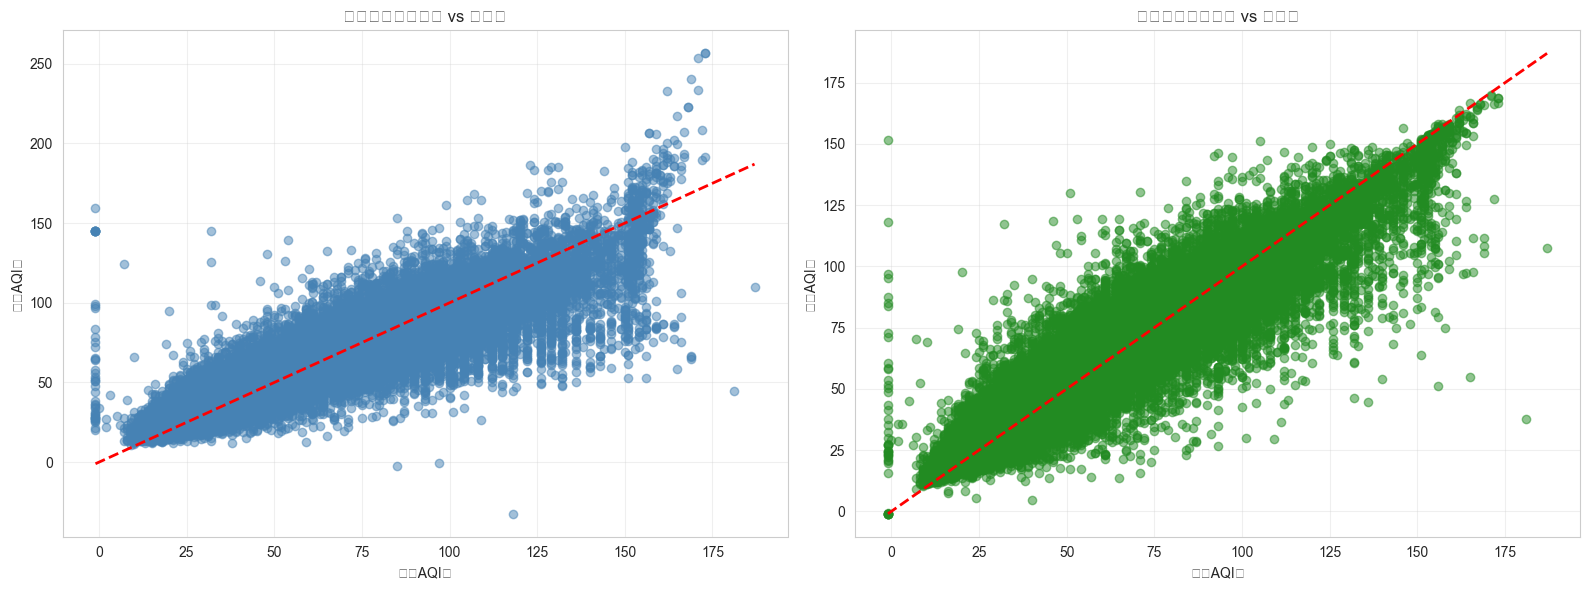

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 准备特征和目标变量
features = ['pm2.5', 'pm10', 'o3', 'no2', 'so2', 'co', 'windspeed', 'hour', 'day_of_week']
X = df[features].fillna(df[features].mean())  # 填充特征中的缺失值
y = df['aqi'].fillna(df['aqi'].mean())  # 填充目标变量中的缺失值

# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 1. 线性回归模型
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# 2. 随机森林回归模型
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 评估模型
print("="*60)
print("回归模型性能评估")
print("="*60)

models = {
    '线性回归': (y_pred_lr, lr_model.coef_),
    '随机森林': (y_pred_rf, rf_model.feature_importances_)
}

for model_name, (y_pred, coef_importances) in models.items():
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n{model_name}:")
    print(f"  均方误差 (MSE): {mse:.2f}")
    print(f"  均方根误差 (RMSE): {rmse:.2f}")
    print(f"  平均绝对误差 (MAE): {mae:.2f}")
    print(f"  决定系数 (R²): {r2:.4f}")

# 特征重要性可视化
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 线性回归系数
lr_coef_df = pd.DataFrame({
    '特征': features,
    '系数': lr_model.coef_
}).sort_values('系数', key=abs, ascending=False)

axes[0].barh(lr_coef_df['特征'], lr_coef_df['系数'], color='steelblue')
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_xlabel('系数值')
axes[0].set_title('线性回归特征系数（影响AQI的因素）')
axes[0].grid(True, alpha=0.3, axis='x')

# 随机森林特征重要性
rf_importances_df = pd.DataFrame({
    '特征': features,
    '重要性': rf_model.feature_importances_
}).sort_values('重要性', ascending=False)

axes[1].barh(rf_importances_df['特征'], rf_importances_df['重要性'], color='forestgreen')
axes[1].set_xlabel('重要性分数')
axes[1].set_title('随机森林特征重要性')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# 预测值与实际值对比图
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 线性回归预测对比
axes[0].scatter(y_test, y_pred_lr, alpha=0.5, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('实际AQI值')
axes[0].set_ylabel('预测AQI值')
axes[0].set_title('线性回归：预测值 vs 实际值')
axes[0].grid(True, alpha=0.3)

# 随机森林预测对比
axes[1].scatter(y_test, y_pred_rf, alpha=0.5, color='forestgreen')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('实际AQI值')
axes[1].set_ylabel('预测AQI值')
axes[1].set_title('随机森林：预测值 vs 实际值')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [22]:
pip install windrose


Note: you may need to restart the kernel to use updated packages.


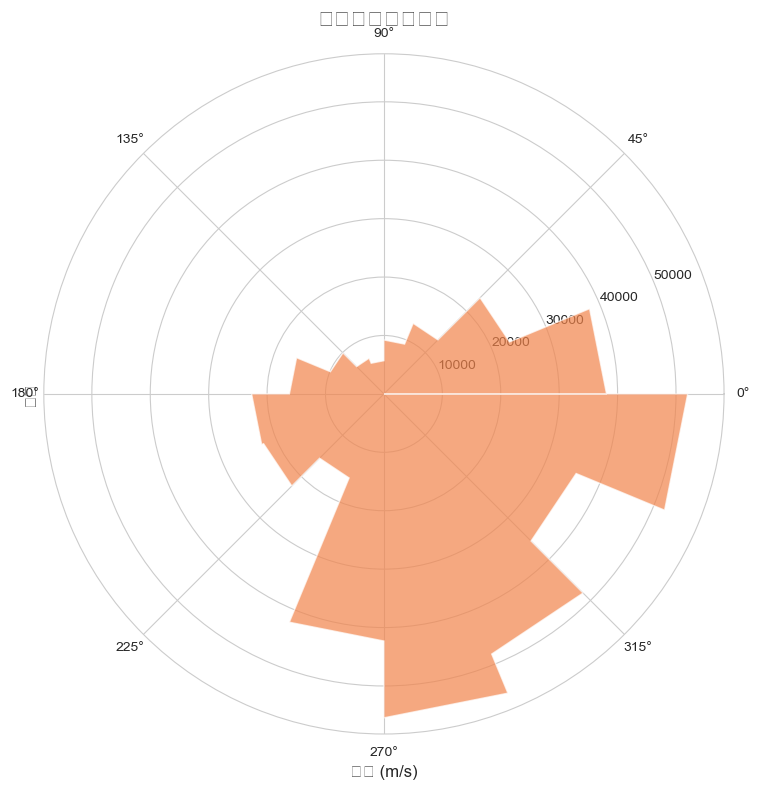

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# 假设 'winddirec' 是风向，'windspeed' 是风速，'pm2.5' 是 PM2.5 浓度
wind_data = df[['winddirec', 'windspeed', 'pm2.5']].dropna()

# 定义风速的分类
wind_speed_bins = np.arange(0, 8, 1)

# 创建一个极坐标图
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})

# 将风向转换为角度（0° 为北，顺时针）
angles = np.radians(wind_data['winddirec'])

# 将风速按类别进行分组
wind_speeds = wind_data['windspeed']

# 绘制风玫瑰图
ax.hist(angles, bins=16, weights=wind_speeds, histtype='stepfilled', color=plt.cm.plasma(0.7), alpha=0.7)

# 添加图例和标题
ax.set_title('风向与风速关系图', fontsize=16, pad=20)
ax.set_xlabel('风速 (m/s)', fontsize=12)
ax.set_ylabel('频率', fontsize=12)

plt.tight_layout()
plt.show()
